# ShanghaiTech - EDA

## Dataset context

ShanghaiTech was introduced in the MCNN paper, *Single-Image Crowd Counting via Multi-Column Convolutional Neural Network* (CVPR 2016). The dataset contains 1,198 annotated crowd images with 330,165 annotated head centers. It has two parts:

- **Part A**: 482 dense crowd images randomly crawled from the Internet. Standard split: 300 train, 182 test.
- **Part B**: 716 images from busy streets in metropolitan Shanghai. Standard split: 400 train, 316 test.

The paper reports that Part A is much denser than Part B, so this notebook explicitly compares the two parts instead of only aggregating all images.

References used for the research notes:

- Zhang et al., CVPR 2016: https://openaccess.thecvf.com/content_cvpr_2016/html/Zhang_Single-Image_Crowd_Counting_CVPR_2016_paper.html
- PDF: https://openaccess.thecvf.com/content_cvpr_2016/papers/Zhang_Single-Image_Crowd_Counting_CVPR_2016_paper.pdf


## 1. Mount Google Drive

In [1]:
# try:
#     from google.colab import drive
#     drive.mount("/content/drive")
# except Exception as exc:
#     print("Drive mount skipped. This is expected outside Colab:", exc)


## 2. Configure paths

Edit `DATA_ROOT` only if the dataset is not in `MyDrive/data/ShanghaiTech`.


In [2]:
from pathlib import Path

CANDIDATE_ROOTS = [
    Path("/content/drive/MyDrive/Crowd_flow_est/data/ShanghaiTech"),
    Path("/content/drive/MyDrive/ShanghaiTech"),
    Path("./data/ShanghaiTech"),
    Path("../data/ShanghaiTech"),
]

DATA_ROOT = next((p for p in CANDIDATE_ROOTS if p.exists()), CANDIDATE_ROOTS[0])
OUTPUT_DIR = Path("/content/drive/MyDrive/Crowd_flow_est/crowd_counting_eda_outputs/ShanghaiTech") if Path("/content/drive/MyDrive").exists() else Path("./crowd_counting_eda_outputs/ShanghaiTech")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)


DATA_ROOT: ..\data\ShanghaiTech
OUTPUT_DIR: crowd_counting_eda_outputs\ShanghaiTech


## 3. Imports and helper functions


In [3]:
from pathlib import Path
from functools import lru_cache
import math
import os
import random
import re
import warnings

import numpy as np
import pandas as pd
from PIL import Image, ImageFile, UnidentifiedImageError
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)
print("Ready.")


Ready.


In [4]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def print_tree(root, max_depth=3, max_entries=80):
    """Print a compact directory tree so paths can be verified quickly."""
    root = Path(root)
    print(f"Root: {root}")
    if not root.exists():
        print("Path does not exist. Edit DATA_ROOT in the path cell above.")
        return
    shown = 0
    for current, dirs, files in os.walk(root):
        current = Path(current)
        depth = len(current.relative_to(root).parts)
        if depth > max_depth:
            dirs[:] = []
            continue
        indent = "  " * depth
        if depth == 0:
            print(f"{current.name}/")
        else:
            print(f"{indent}{current.name}/")
        shown += 1
        for fname in sorted(files)[:8]:
            if shown >= max_entries:
                print("  ... tree output truncated")
                return
            print(f"{indent}  {fname}")
            shown += 1
        dirs[:] = sorted(dirs)[:12]
        if shown >= max_entries:
            print("  ... tree output truncated")
            return


def is_image_file(path):
    return Path(path).suffix.lower() in IMAGE_SUFFIXES


def list_images(folder, recursive=True):
    folder = Path(folder)
    if not folder.exists():
        return []
    pattern = "**/*" if recursive else "*"
    return sorted([p for p in folder.glob(pattern) if p.is_file() and is_image_file(p)])


def list_mats(folder, recursive=True):
    folder = Path(folder)
    if not folder.exists():
        return []
    pattern = "**/*.mat" if recursive else "*.mat"
    return sorted([p for p in folder.glob(pattern) if p.is_file()])


def safe_image_info(image_path):
    """Return width, height, mode, and any error string."""
    try:
        with Image.open(image_path) as im:
            width, height = im.size
            mode = im.mode
        return width, height, mode, None
    except Exception as exc:
        return np.nan, np.nan, None, repr(exc)


def _points_candidate(obj):
    """Convert a numeric object to an Nx2 coordinate array when possible."""
    try:
        arr = np.asarray(obj)
    except Exception:
        return None
    if arr.size == 0:
        return np.empty((0, 2), dtype=float)
    if not np.issubdtype(arr.dtype, np.number):
        return None
    arr = np.squeeze(arr)
    if arr.ndim == 1:
        if arr.shape[0] == 2:
            arr = arr.reshape(1, 2)
        else:
            return None
    if arr.ndim != 2:
        return None
    if arr.shape[1] == 2:
        pts = arr
    elif arr.shape[0] == 2:
        pts = arr.T
    else:
        return None
    pts = pts.astype(float)
    pts = pts[np.isfinite(pts).all(axis=1)]
    return pts


def _walk_mat_object(obj, path="root"):
    """Yield all numeric Nx2 arrays reachable inside nested MATLAB structs/cells."""
    pts = _points_candidate(obj)
    if pts is not None:
        yield path, pts
    if hasattr(obj, "_fieldnames"):
        for field in obj._fieldnames:
            try:
                value = getattr(obj, field)
            except Exception:
                continue
            yield from _walk_mat_object(value, f"{path}.{field}")
    elif isinstance(obj, np.ndarray) and obj.dtype == object:
        for idx, value in enumerate(obj.flat):
            yield from _walk_mat_object(value, f"{path}[{idx}]")
    elif isinstance(obj, (list, tuple)):
        for idx, value in enumerate(obj):
            yield from _walk_mat_object(value, f"{path}[{idx}]")


def extract_points_from_mat(mat_path):
    """Robustly extract point labels from UCF-QNRF or ShanghaiTech .mat files.

    UCF-QNRF usually stores points in `annPoints`.
    ShanghaiTech usually stores points nested under `image_info`.
    The function recursively searches for numeric Nx2 arrays and returns the best candidate.
    """
    mat_path = Path(mat_path)
    if not mat_path.exists():
        return np.empty((0, 2), dtype=float)
    mat = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    keys = [k for k in mat.keys() if not k.startswith("__")]

    candidates = []
    priority_names = ["annPoints", "location", "image_info"]
    for key in priority_names + [k for k in keys if k not in priority_names]:
        if key not in mat:
            continue
        for candidate_path, pts in _walk_mat_object(mat[key], path=key):
            if pts is None or pts.ndim != 2 or pts.shape[1] != 2:
                continue
            priority = 10 if key == "annPoints" else 8 if "location" in candidate_path.lower() else 6 if key == "image_info" else 1
            candidates.append((priority, pts.shape[0], candidate_path, pts))
    if not candidates:
        return np.empty((0, 2), dtype=float)
    candidates.sort(key=lambda x: (x[0], x[1]), reverse=True)
    return candidates[0][3]


_POINTS_CACHE = {}


def get_points(label_path):
    """Cached point-loader. Returns empty Nx2 array when label is missing."""
    if label_path is None or (isinstance(label_path, float) and np.isnan(label_path)) or pd.isna(label_path):
        return np.empty((0, 2), dtype=float)
    key = str(label_path)
    if key not in _POINTS_CACHE:
        _POINTS_CACHE[key] = extract_points_from_mat(Path(key))
    return _POINTS_CACHE[key]


def normalize_stem(stem):
    s = stem.lower()
    s = re.sub(r"^gt[_-]", "", s)
    s = re.sub(r"[_-]ann$", "", s)
    return s


def pair_label_for_image(image_path, mat_files):
    """Pair an image with a .mat label by normalizing common naming conventions."""
    image_path = Path(image_path)
    mat_by_norm = {}
    for mat_file in mat_files:
        mat_by_norm.setdefault(normalize_stem(mat_file.stem), mat_file)
    return mat_by_norm.get(normalize_stem(image_path.stem))


def points_bounds_summary(points, width, height):
    """Count points inside image bounds, accepting common 0-based and 1-based conventions."""
    if points is None or len(points) == 0 or pd.isna(width) or pd.isna(height):
        return 0, "empty_or_unknown"
    x = points[:, 0]
    y = points[:, 1]
    zero_based = (x >= 0) & (x < width) & (y >= 0) & (y < height)
    one_based = (x >= 1) & (x <= width) & (y >= 1) & (y <= height)
    if one_based.sum() > zero_based.sum():
        return int(one_based.sum()), "one_based_or_closed"
    return int(zero_based.sum()), "zero_based"


def duplicate_point_count(points, decimals=1):
    if points is None or len(points) <= 1:
        return 0
    rounded = np.round(points, decimals=decimals)
    return int(len(rounded) - len(np.unique(rounded, axis=0)))


def add_derived_columns(df):
    df = df.copy()
    df["width"] = pd.to_numeric(df["width"], errors="coerce")
    df["height"] = pd.to_numeric(df["height"], errors="coerce")
    df["count"] = pd.to_numeric(df["count"], errors="coerce")
    df["megapixels"] = (df["width"] * df["height"]) / 1_000_000
    df["aspect_ratio"] = df["width"] / df["height"]
    df["count_per_megapixel"] = df["count"] / df["megapixels"]
    df["out_of_bounds_points"] = df["count"] - df["points_in_bounds"]
    df["orientation"] = np.select(
        [df["aspect_ratio"] > 1.10, df["aspect_ratio"] < 0.90],
        ["landscape", "portrait"],
        default="near_square",
    )
    return df


def save_show(fig, filename, dpi=170):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


def count_label(row):
    if pd.isna(row.get("count", np.nan)):
        return "unlabeled"
    return str(int(row["count"]))


def plot_annotated_samples(sample_df, title, filename, max_points=2500, ncols=3):
    sample_df = sample_df.copy()
    sample_df = sample_df[sample_df["image_path"].notna()]
    if sample_df.empty:
        print("No samples to plot.")
        return
    n = len(sample_df)
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 4.3 * nrows), squeeze=False)
    axes_flat = axes.ravel()
    for ax, (_, row) in zip(axes_flat, sample_df.iterrows()):
        image_path = Path(row["image_path"])
        try:
            img = Image.open(image_path).convert("RGB")
        except Exception as exc:
            ax.text(0.5, 0.5, f"Could not open image\n{exc}", ha="center", va="center")
            ax.axis("off")
            continue
        ax.imshow(img)
        pts = get_points(row.get("label_path"))
        shown = len(pts)
        suffix = ""
        if len(pts) > max_points:
            idx = RNG.choice(len(pts), size=max_points, replace=False)
            pts = pts[idx]
            suffix = f"; showing {max_points}/{shown} pts"
        if len(pts):
            ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.65)
        part_text = row.get("part", "")
        split_text = row.get("split", "")
        ax.set_title(f"{row.get('image_id', image_path.stem)}\n{part_text} {split_text} | count={count_label(row)}{suffix}", fontsize=10)
        ax.axis("off")
    for ax in axes_flat[n:]:
        ax.axis("off")
    fig.suptitle(title, fontsize=16, y=1.02)
    save_show(fig, filename)


def stratified_sample(df, group_cols, n_each=2, seed=SEED):
    chunks = []
    for _, group in df.groupby(group_cols, dropna=False):
        if len(group) == 0:
            continue
        chunks.append(group.sample(n=min(n_each, len(group)), random_state=seed))
    if not chunks:
        return df.head(0)
    return pd.concat(chunks).sample(frac=1, random_state=seed).reset_index(drop=True)


def plot_normalized_spatial_heatmap(rows_df, title, filename, bins=70, max_points_per_image=2000):
    xs = []
    ys = []
    for row in tqdm(rows_df.itertuples(index=False), total=len(rows_df), desc="Loading points"):
        pts = get_points(getattr(row, "label_path", None))
        if len(pts) == 0 or pd.isna(row.width) or pd.isna(row.height):
            continue
        if len(pts) > max_points_per_image:
            idx = RNG.choice(len(pts), max_points_per_image, replace=False)
            pts = pts[idx]
        xs.append(np.clip(pts[:, 0] / row.width, 0, 1))
        ys.append(np.clip(pts[:, 1] / row.height, 0, 1))
    if not xs:
        print("No points available for heatmap.")
        return
    x = np.concatenate(xs)
    y = np.concatenate(ys)
    heat, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[[0, 1], [0, 1]])
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    im = ax.imshow(heat.T, origin="upper", extent=[0, 1, 1, 0], aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Normalized x position")
    ax.set_ylabel("Normalized y position")
    fig.colorbar(im, ax=ax, label="Sampled annotation frequency")
    save_show(fig, filename)


def make_density_preview(row, filename, max_side=900, sigma=7):
    image_path = Path(row["image_path"])
    try:
        img = Image.open(image_path).convert("RGB")
    except Exception as exc:
        print(f"Could not open image: {exc}")
        return
    pts = get_points(row.get("label_path"))
    width, height = img.size
    scale = min(max_side / max(width, height), 1.0)
    new_size = (max(1, int(round(width * scale))), max(1, int(round(height * scale))))
    img_small = img.resize(new_size)
    dot_map = np.zeros((new_size[1], new_size[0]), dtype=np.float32)
    if len(pts):
        pts_scaled = pts * scale
        xi = np.clip(np.rint(pts_scaled[:, 0]).astype(int), 0, new_size[0] - 1)
        yi = np.clip(np.rint(pts_scaled[:, 1]).astype(int), 0, new_size[1] - 1)
        np.add.at(dot_map, (yi, xi), 1.0)
    density = gaussian_filter(dot_map, sigma=sigma)
    if density.sum() > 0:
        density *= len(pts) / density.sum()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(img_small)
    axes[0].set_title("Image")
    axes[0].axis("off")
    axes[1].imshow(img_small)
    if len(pts):
        pts_scaled = pts * scale
        draw_pts = pts_scaled
        if len(draw_pts) > 3500:
            idx = RNG.choice(len(draw_pts), 3500, replace=False)
            draw_pts = draw_pts[idx]
        axes[1].scatter(draw_pts[:, 0], draw_pts[:, 1], s=2, alpha=0.65)
    axes[1].set_title(f"Point annotations: {len(pts):,}")
    axes[1].axis("off")
    im = axes[2].imshow(density)
    axes[2].set_title(f"Gaussian density preview\nIntegral approx: {density.sum():.1f}")
    axes[2].axis("off")
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    fig.suptitle(f"{row.get('image_id', image_path.stem)}", fontsize=16, y=1.02)
    save_show(fig, filename)


## 4. Inspect folder structure

This quick tree helps verify whether paths are as expected before indexing labels and images.


In [5]:
print_tree(DATA_ROOT, max_depth=4, max_entries=100)


Root: ..\data\ShanghaiTech
ShanghaiTech/
  .DS_Store
  part_A/
    .DS_Store
    test_data/
      ground_truth/
        GT_IMG_1.mat
        GT_IMG_10.mat
        GT_IMG_100.mat
        GT_IMG_101.mat
        GT_IMG_102.mat
        GT_IMG_103.mat
        GT_IMG_104.mat
        GT_IMG_105.mat
      images/
        IMG_1.jpg
        IMG_10.jpg
        IMG_100.jpg
        IMG_101.jpg
        IMG_102.jpg
        IMG_103.jpg
        IMG_104.jpg
        IMG_105.jpg
    train_data/
      ground_truth/
        GT_IMG_1.mat
        GT_IMG_10.mat
        GT_IMG_100.mat
        GT_IMG_101.mat
        GT_IMG_102.mat
        GT_IMG_103.mat
        GT_IMG_104.mat
        GT_IMG_105.mat
      images/
        IMG_1.jpg
        IMG_10.jpg
        IMG_100.jpg
        IMG_101.jpg
        IMG_102.jpg
        IMG_103.jpg
        IMG_104.jpg
        IMG_105.jpg
  part_B/
    .DS_Store
    test_data/
      ground_truth/
        GT_IMG_1.mat
        GT_IMG_10.mat
        GT_IMG_100.mat
        GT_IMG_101.mat


## 5. Build the ShanghaiTech metadata table

The code below discovers `part_A` and `part_B`, pairs each image with its `.mat` file, extracts the point annotations, and computes image-level metadata.


In [6]:
def has_split_structure(path):
    path = Path(path)
    if not path.exists() or not path.is_dir():
        return False
    child_names = [p.name.lower() for p in path.iterdir() if p.is_dir()]
    return any("train" in name for name in child_names) and any("test" in name for name in child_names)


def discover_shanghai_parts(root):
    root = Path(root)
    patterns = {
        "part_A": ["part_a", "part-a", "parta"],
        "part_B": ["part_b", "part-b", "partb"],
    }
    found = {}
    search_space = [root] + [p for p in root.rglob("*") if p.is_dir()] if root.exists() else []
    for path in search_space:
        low = path.name.lower()
        for part, tokens in patterns.items():
            if part in found:
                continue
            if any(token in low for token in tokens) and has_split_structure(path):
                found[part] = path
    return found


def find_split_dir(part_dir, split):
    part_dir = Path(part_dir)
    candidates = [
        part_dir / f"{split}_data",
        part_dir / split,
        part_dir / split.capitalize(),
        part_dir / f"{split.capitalize()}_data",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    for child in part_dir.iterdir():
        if child.is_dir() and split.lower() in child.name.lower():
            return child
    return None


def choose_image_roots(split_dir):
    split_dir = Path(split_dir)
    candidates = [split_dir / "images", split_dir / "Images", split_dir / "imgs", split_dir]
    existing = [p for p in candidates if p.exists()]
    return existing if existing else [split_dir]


def choose_label_roots(split_dir):
    split_dir = Path(split_dir)
    candidates = [
        split_dir / "ground_truth",
        split_dir / "ground-truth",
        split_dir / "GroundTruth",
        split_dir / "labels",
        split_dir / "annotations",
        split_dir,
    ]
    existing = [p for p in candidates if p.exists()]
    return existing if existing else [split_dir]


def build_shanghai_index(root):
    parts = discover_shanghai_parts(root)
    if not parts:
        raise FileNotFoundError(
            f"Could not discover part_A/part_B folders under {root}. "
            "Check DATA_ROOT and the printed directory tree."
        )
    rows = []
    for part, part_dir in sorted(parts.items()):
        for split in ["train", "test"]:
            split_dir = find_split_dir(part_dir, split)
            if split_dir is None:
                print(f"Missing {split} split for {part}: {part_dir}")
                continue
            image_roots = choose_image_roots(split_dir)
            label_roots = choose_label_roots(split_dir)
            image_files = []
            for image_root in image_roots:
                image_files.extend(list_images(image_root, recursive=True))
            image_files = sorted(set(image_files))
            mat_files = []
            for label_root in label_roots:
                mat_files.extend(list_mats(label_root, recursive=True))
            mat_files = sorted(set(mat_files))
            print(f"{part} / {split}: {len(image_files)} images, {len(mat_files)} mat files")
            for image_path in tqdm(image_files, desc=f"Indexing {part} {split}"):
                label_path = pair_label_for_image(image_path, mat_files)
                width, height, mode, image_error = safe_image_info(image_path)
                has_label = label_path is not None
                pts = get_points(str(label_path)) if has_label else np.empty((0, 2), dtype=float)
                points_in_bounds, coord_convention = points_bounds_summary(pts, width, height)
                rows.append({
                    "dataset": "ShanghaiTech",
                    "part": part,
                    "split": split,
                    "image_id": image_path.stem,
                    "image_path": str(image_path),
                    "label_path": str(label_path) if label_path is not None else None,
                    "has_label": bool(has_label),
                    "width": width,
                    "height": height,
                    "mode": mode,
                    "image_error": image_error,
                    "count": int(len(pts)) if has_label else np.nan,
                    "points_in_bounds": int(points_in_bounds),
                    "coord_convention_guess": coord_convention,
                    "duplicate_points_rounded_0p1px": duplicate_point_count(pts, decimals=1) if has_label else np.nan,
                })
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No images were indexed. Check DATA_ROOT.")
    return add_derived_columns(df)


df = build_shanghai_index(DATA_ROOT)
print("Indexed rows:", len(df))
display(df.head())


part_A / train: 272 images, 280 mat files


Indexing part_A train:   0%|          | 0/272 [00:00<?, ?it/s]

part_A / test: 165 images, 175 mat files


Indexing part_A test:   0%|          | 0/165 [00:00<?, ?it/s]

part_B / train: 364 images, 382 mat files


Indexing part_B train:   0%|          | 0/364 [00:00<?, ?it/s]

part_B / test: 284 images, 301 mat files


Indexing part_B test:   0%|          | 0/284 [00:00<?, ?it/s]

Indexed rows: 1085


,dataset,part,split,image_id,image_path,label_path,has_label,width,height,mode,image_error,count,points_in_bounds,coord_convention_guess,duplicate_points_rounded_0p1px,megapixels,aspect_ratio,count_per_megapixel,out_of_bounds_points,orientation
0,ShanghaiTech,part_A,train,IMG_1,..\data\ShanghaiTech\part_A\train_data\images\IMG_1.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_1.mat,True,1024,768,RGB,None,1546.0,1546,zero_based,0.0,0.786432,1.333333,1965.840658,0.0,landscape
1,ShanghaiTech,part_A,train,IMG_10,..\data\ShanghaiTech\part_A\train_data\images\IMG_10.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_10.mat,True,1024,683,RGB,None,920.0,920,zero_based,0.0,0.699392,1.499268,1315.428258,0.0,landscape
2,ShanghaiTech,part_A,train,IMG_100,..\data\ShanghaiTech\part_A\train_data\images\IMG_100.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_100.mat,True,1024,654,RGB,None,373.0,371,zero_based,0.0,0.669696,1.565749,556.969132,2.0,landscape
3,ShanghaiTech,part_A,train,IMG_101,..\data\ShanghaiTech\part_A\train_data\images\IMG_101.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_101.mat,True,1024,768,RGB,None,298.0,298,zero_based,0.0,0.786432,1.333333,378.926595,0.0,landscape
4,ShanghaiTech,part_A,train,IMG_102,..\data\ShanghaiTech\part_A\train_data\images\IMG_102.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_102.mat,True,1024,768,RGB,None,185.0,184,zero_based,0.0,0.786432,1.333333,235.239665,1.0,landscape


## 6. Dataset-level summary and split validation

The expected split sizes are from the original ShanghaiTech protocol. `image_delta` should be 0 when all expected images are present.


In [7]:
expected = pd.DataFrame([
    {"part": "part_A", "split": "train", "expected_images": 300},
    {"part": "part_A", "split": "test", "expected_images": 182},
    {"part": "part_B", "split": "train", "expected_images": 400},
    {"part": "part_B", "split": "test", "expected_images": 316},
])

summary = (
    df.groupby(["part", "split"], dropna=False)
      .agg(
          images=("image_path", "count"),
          labels_found=("has_label", "sum"),
          total_heads=("count", "sum"),
          mean_count=("count", "mean"),
          median_count=("count", "median"),
          min_count=("count", "min"),
          max_count=("count", "max"),
          mean_width=("width", "mean"),
          mean_height=("height", "mean"),
          mean_megapixels=("megapixels", "mean"),
      )
      .reset_index()
)
summary = expected.merge(summary, on=["part", "split"], how="outer")
summary["image_delta"] = summary["images"] - summary["expected_images"]
display(summary)

overall = pd.DataFrame([{
    "images": len(df),
    "labels_found": int(df["has_label"].sum()),
    "total_heads": float(df["count"].sum(skipna=True)),
    "mean_count": float(df["count"].mean(skipna=True)),
    "median_count": float(df["count"].median(skipna=True)),
    "max_count": float(df["count"].max(skipna=True)),
}])
display(overall)


,part,split,expected_images,images,labels_found,total_heads,mean_count,median_count,min_count,max_count,mean_width,mean_height,mean_megapixels,image_delta
0,part_A,test,182,165,159,69157.0,434.949686,308.0,66.0,2256.0,863.430303,574.963636,0.522548,-17
1,part_A,train,300,272,254,136813.0,538.633858,365.0,33.0,3139.0,872.308824,598.852941,0.547602,-28
2,part_B,test,316,284,270,33346.0,123.503704,91.0,9.0,539.0,1024.000000,768.000000,0.786432,-32
3,part_B,train,400,364,348,41599.0,119.537356,96.5,12.0,578.0,1024.000000,768.000000,0.786432,-36


,images,labels_found,total_heads,mean_count,median_count,max_count
0,1085,1031,280915.0,272.468477,159.0,3139.0


## 7. Data quality checks

These checks catch the most common issues before training: missing labels, unreadable images, annotations outside image bounds, and repeated point coordinates.


In [8]:
quality_summary = (
    df.groupby(["part", "split"], dropna=False)
      .agg(
          images=("image_path", "count"),
          unreadable_images=("image_error", lambda s: s.notna().sum()),
          missing_labels=("has_label", lambda s: (~s).sum()),
          total_points=("count", "sum"),
          out_of_bounds_points=("out_of_bounds_points", "sum"),
          images_with_oob=("out_of_bounds_points", lambda s: (s.fillna(0) > 0).sum()),
          duplicate_points=("duplicate_points_rounded_0p1px", "sum"),
      )
      .reset_index()
)
display(quality_summary)

issues = df[
    (df["image_error"].notna()) |
    (~df["has_label"]) |
    (df["out_of_bounds_points"].fillna(0) > 0) |
    (df["duplicate_points_rounded_0p1px"].fillna(0) > 0)
].copy()

print(f"Rows with at least one potential issue: {len(issues)}")
issue_cols = ["part", "split", "image_id", "has_label", "image_error", "count", "points_in_bounds", "out_of_bounds_points", "duplicate_points_rounded_0p1px", "image_path", "label_path"]
display(issues[issue_cols].head(30))


,part,split,images,unreadable_images,missing_labels,total_points,out_of_bounds_points,images_with_oob,duplicate_points
0,part_A,test,165,0,6,69157.0,84.0,36,61.0
1,part_A,train,272,0,18,136813.0,234.0,70,51.0
2,part_B,test,284,0,14,33346.0,69.0,52,30.0
3,part_B,train,364,0,16,41599.0,103.0,79,26.0


Rows with at least one potential issue: 341


,part,split,image_id,has_label,image_error,count,points_in_bounds,out_of_bounds_points,duplicate_points_rounded_0p1px,image_path,label_path
2,part_A,train,IMG_100,True,None,373.0,371,2.0,0.0,..\data\ShanghaiTech\part_A\train_data\images\IMG_100.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_100.mat
4,part_A,train,IMG_102,True,None,185.0,184,1.0,0.0,..\data\ShanghaiTech\part_A\train_data\images\IMG_102.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_102.mat
7,part_A,train,IMG_105,True,None,148.0,147,1.0,0.0,..\data\ShanghaiTech\part_A\train_data\images\IMG_105.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_105.mat
15,part_A,train,IMG_112,True,None,2673.0,2672,1.0,0.0,..\data\ShanghaiTech\part_A\train_data\images\IMG_112.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_112.mat
21,part_A,train,IMG_118,True,None,1621.0,1620,1.0,0.0,..\data\ShanghaiTech\part_A\train_data\images\IMG_118.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_118.mat
29,part_A,train,IMG_125,False,None,NaN,0,NaN,NaN,..\data\ShanghaiTech\part_A\train_data\images\IMG_125.jpg,None
32,part_A,train,IMG_13,False,None,NaN,0,NaN,NaN,..\data\ShanghaiTech\part_A\train_data\images\IMG_13.jpg,None
43,part_A,train,IMG_141,True,None,502.0,406,96.0,0.0,..\data\ShanghaiTech\part_A\train_data\images\IMG_141.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_141.mat
45,part_A,train,IMG_143,True,None,1297.0,1296,1.0,1.0,..\data\ShanghaiTech\part_A\train_data\images\IMG_143.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_143.mat
46,part_A,train,IMG_144,True,None,777.0,777,0.0,1.0,..\data\ShanghaiTech\part_A\train_data\images\IMG_144.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_144.mat


## 8. Count distribution analysis


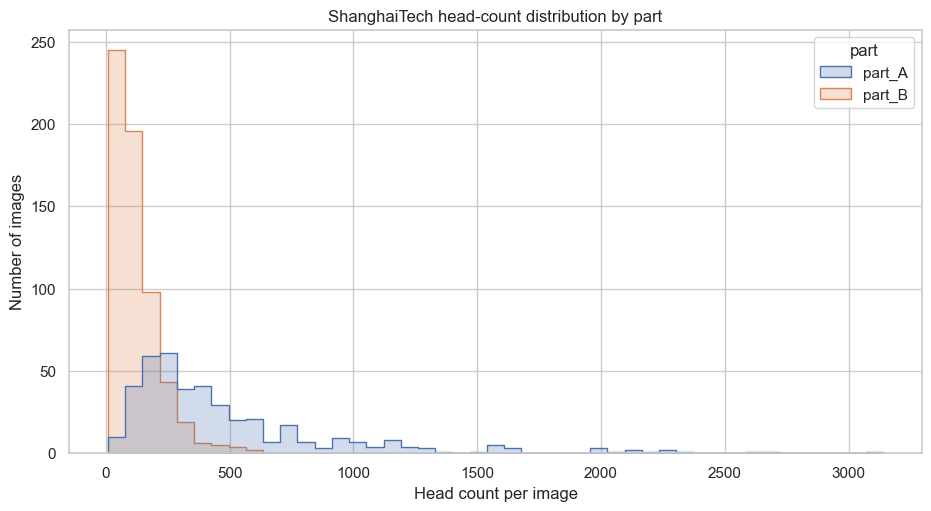

Saved: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_count_hist_by_part.png


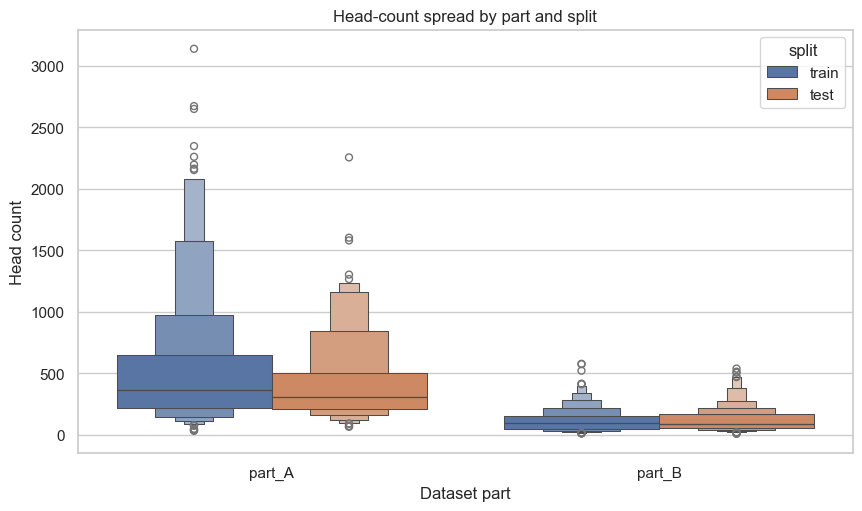

Saved: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_count_boxen_by_part_split.png


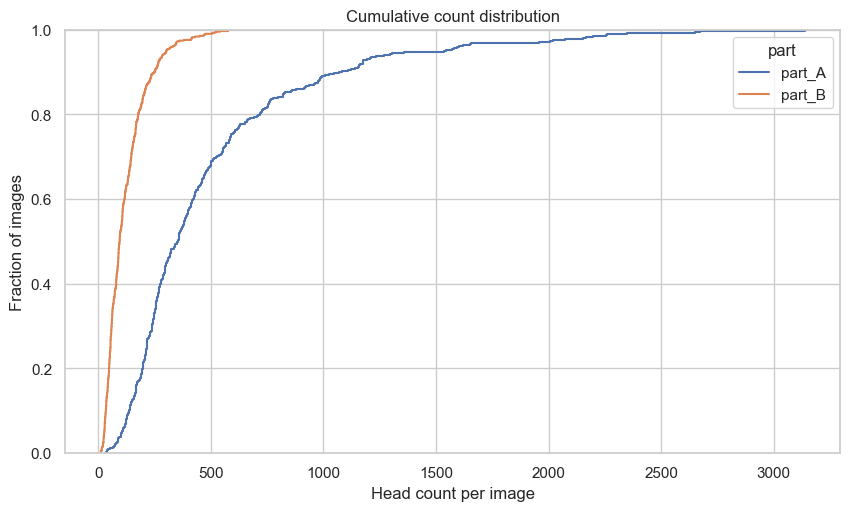

Saved: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_count_ecdf_by_part.png


In [9]:
labeled_df = df[df["has_label"] & df["count"].notna()].copy()
if labeled_df.empty:
    raise RuntimeError("No labels were loaded. Check .mat paths and the parser.")

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.histplot(data=labeled_df, x="count", hue="part", bins=45, element="step", stat="count", common_norm=False, ax=ax)
ax.set_title("ShanghaiTech head-count distribution by part")
ax.set_xlabel("Head count per image")
ax.set_ylabel("Number of images")
save_show(fig, "shanghaitech_count_hist_by_part.png")

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxenplot(data=labeled_df, x="part", y="count", hue="split", ax=ax)
ax.set_title("Head-count spread by part and split")
ax.set_xlabel("Dataset part")
ax.set_ylabel("Head count")
save_show(fig, "shanghaitech_count_boxen_by_part_split.png")

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.ecdfplot(data=labeled_df, x="count", hue="part", ax=ax)
ax.set_title("Cumulative count distribution")
ax.set_xlabel("Head count per image")
ax.set_ylabel("Fraction of images")
save_show(fig, "shanghaitech_count_ecdf_by_part.png")


## 9. Resolution, aspect ratio, and crowd density per megapixel

Crowd counting models are sensitive to scale. These plots help decide whether resizing, tiling, or multi-scale augmentation is necessary.


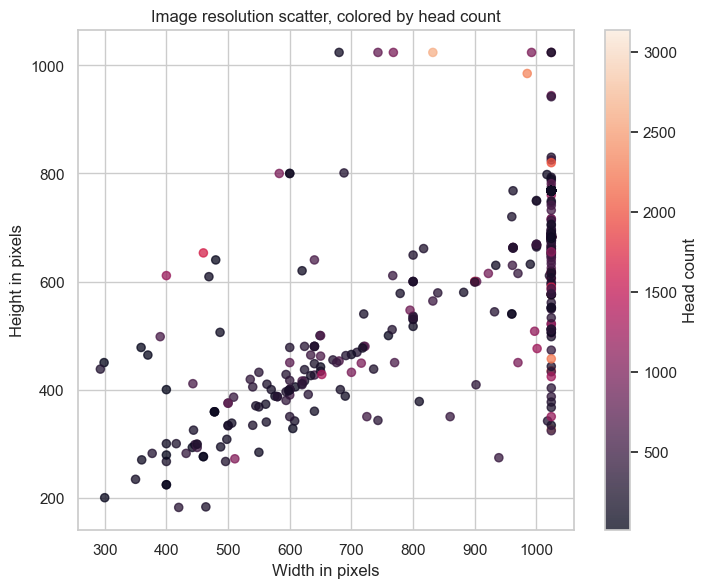

Saved: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_resolution_scatter_count.png


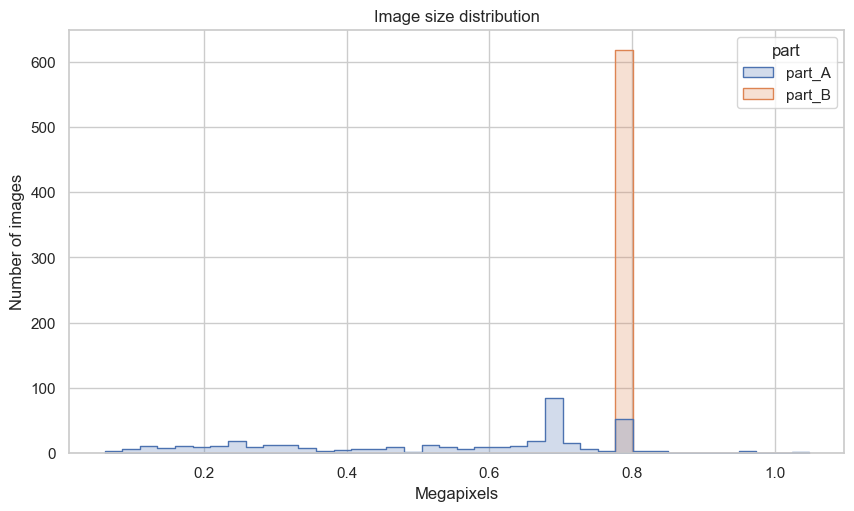

Saved: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_megapixels_hist.png


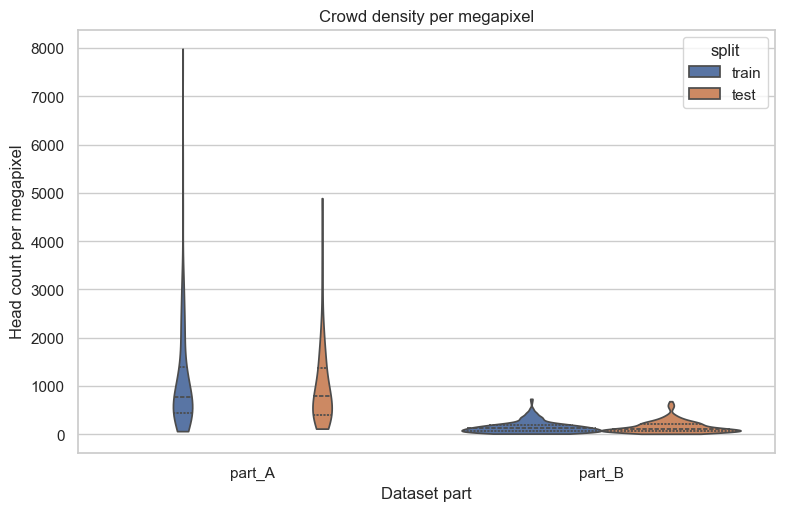

Saved: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_count_per_mp_violin.png


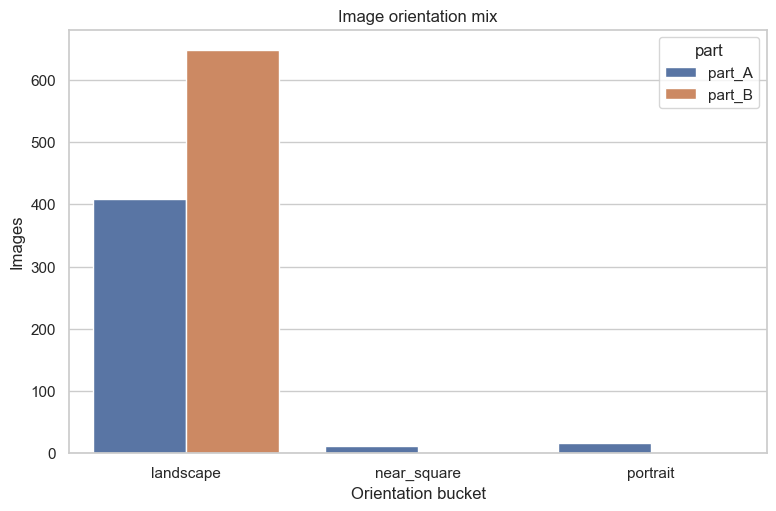

Saved: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_orientation_mix.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 6.5))
scatter = ax.scatter(labeled_df["width"], labeled_df["height"], c=labeled_df["count"], s=35, alpha=0.75)
ax.set_title("Image resolution scatter, colored by head count")
ax.set_xlabel("Width in pixels")
ax.set_ylabel("Height in pixels")
fig.colorbar(scatter, ax=ax, label="Head count")
save_show(fig, "shanghaitech_resolution_scatter_count.png")

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(data=labeled_df, x="megapixels", hue="part", bins=40, element="step", common_norm=False, ax=ax)
ax.set_title("Image size distribution")
ax.set_xlabel("Megapixels")
ax.set_ylabel("Number of images")
save_show(fig, "shanghaitech_megapixels_hist.png")

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.violinplot(data=labeled_df, x="part", y="count_per_megapixel", hue="split", cut=0, inner="quartile", ax=ax)
ax.set_title("Crowd density per megapixel")
ax.set_xlabel("Dataset part")
ax.set_ylabel("Head count per megapixel")
save_show(fig, "shanghaitech_count_per_mp_violin.png")

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.countplot(data=df, x="orientation", hue="part", ax=ax)
ax.set_title("Image orientation mix")
ax.set_xlabel("Orientation bucket")
ax.set_ylabel("Images")
save_show(fig, "shanghaitech_orientation_mix.png")


## 10. Extremes and inspection tables

The highest-count images are useful for stress-testing visualization and memory usage. The lowest-count images are useful for checking sparse cases.


In [11]:
inspect_cols = ["part", "split", "image_id", "width", "height", "megapixels", "count", "count_per_megapixel", "image_path", "label_path"]

print("Highest-count images")
display(labeled_df.sort_values("count", ascending=False)[inspect_cols].head(12))

print("Lowest-count images")
display(labeled_df.sort_values("count", ascending=True)[inspect_cols].head(12))

print("Most crowded per megapixel")
display(labeled_df.sort_values("count_per_megapixel", ascending=False)[inspect_cols].head(12))


Highest-count images


,part,split,image_id,width,height,megapixels,count,count_per_megapixel,image_path,label_path
167,part_A,train,IMG_268,900,600,0.540000,3139.0,5812.962963,..\data\ShanghaiTech\part_A\train_data\images\IMG_268.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_268.mat
15,part_A,train,IMG_112,1024,327,0.334848,2673.0,7982.726491,..\data\ShanghaiTech\part_A\train_data\images\IMG_112.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_112.mat
265,part_A,train,IMG_92,832,1024,0.851968,2650.0,3110.445463,..\data\ShanghaiTech\part_A\train_data\images\IMG_92.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_92.mat
223,part_A,train,IMG_50,985,985,0.970225,2348.0,2420.057203,..\data\ShanghaiTech\part_A\train_data\images\IMG_50.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_50.mat
24,part_A,train,IMG_120,1024,768,0.786432,2261.0,2875.010173,..\data\ShanghaiTech\part_A\train_data\images\IMG_120.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_120.mat
428,part_A,test,IMG_90,1024,457,0.467968,2256.0,4820.842451,..\data\ShanghaiTech\part_A\test_data\images\IMG_90.jpg,..\data\ShanghaiTech\part_A\test_data\ground_truth\GT_IMG_90.mat
161,part_A,train,IMG_262,1024,576,0.589824,2197.0,3724.839952,..\data\ShanghaiTech\part_A\train_data\images\IMG_262.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_262.mat
199,part_A,train,IMG_299,1024,681,0.697344,2164.0,3103.203010,..\data\ShanghaiTech\part_A\train_data\images\IMG_299.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_299.mat
256,part_A,train,IMG_84,1024,435,0.445440,2153.0,4833.423132,..\data\ShanghaiTech\part_A\train_data\images\IMG_84.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_84.mat
51,part_A,train,IMG_149,1024,683,0.699392,2072.0,2962.573206,..\data\ShanghaiTech\part_A\train_data\images\IMG_149.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_149.mat


Lowest-count images


,part,split,image_id,width,height,megapixels,count,count_per_megapixel,image_path,label_path
894,part_B,test,IMG_198,1024,768,0.786432,9.0,11.444092,..\data\ShanghaiTech\part_B\test_data\images\IMG_198.jpg,..\data\ShanghaiTech\part_B\test_data\ground_truth\GT_IMG_198.mat
867,part_B,test,IMG_172,1024,768,0.786432,11.0,13.987223,..\data\ShanghaiTech\part_B\test_data\images\IMG_172.jpg,..\data\ShanghaiTech\part_B\test_data\ground_truth\GT_IMG_172.mat
500,part_B,train,IMG_158,1024,768,0.786432,12.0,15.258789,..\data\ShanghaiTech\part_B\train_data\images\IMG_158.jpg,..\data\ShanghaiTech\part_B\train_data\ground_truth\GT_IMG_158.mat
598,part_B,train,IMG_255,1024,768,0.786432,13.0,16.530355,..\data\ShanghaiTech\part_B\train_data\images\IMG_255.jpg,..\data\ShanghaiTech\part_B\train_data\ground_truth\GT_IMG_255.mat
791,part_B,train,IMG_88,1024,768,0.786432,14.0,17.801921,..\data\ShanghaiTech\part_B\train_data\images\IMG_88.jpg,..\data\ShanghaiTech\part_B\train_data\ground_truth\GT_IMG_88.mat
672,part_B,train,IMG_332,1024,768,0.786432,15.0,19.073486,..\data\ShanghaiTech\part_B\train_data\images\IMG_332.jpg,..\data\ShanghaiTech\part_B\train_data\ground_truth\GT_IMG_332.mat
866,part_B,test,IMG_171,1024,768,0.786432,15.0,19.073486,..\data\ShanghaiTech\part_B\test_data\images\IMG_171.jpg,..\data\ShanghaiTech\part_B\test_data\ground_truth\GT_IMG_171.mat
515,part_B,train,IMG_171,1024,768,0.786432,15.0,19.073486,..\data\ShanghaiTech\part_B\train_data\images\IMG_171.jpg,..\data\ShanghaiTech\part_B\train_data\ground_truth\GT_IMG_171.mat
629,part_B,train,IMG_288,1024,768,0.786432,16.0,20.345052,..\data\ShanghaiTech\part_B\train_data\images\IMG_288.jpg,..\data\ShanghaiTech\part_B\train_data\ground_truth\GT_IMG_288.mat
694,part_B,train,IMG_355,1024,768,0.786432,19.0,24.159749,..\data\ShanghaiTech\part_B\train_data\images\IMG_355.jpg,..\data\ShanghaiTech\part_B\train_data\ground_truth\GT_IMG_355.mat


Most crowded per megapixel


,part,split,image_id,width,height,megapixels,count,count_per_megapixel,image_path,label_path
15,part_A,train,IMG_112,1024,327,0.334848,2673.0,7982.726491,..\data\ShanghaiTech\part_A\train_data\images\IMG_112.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_112.mat
198,part_A,train,IMG_298,511,272,0.138992,1046.0,7525.612985,..\data\ShanghaiTech\part_A\train_data\images\IMG_298.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_298.mat
167,part_A,train,IMG_268,900,600,0.540000,3139.0,5812.962963,..\data\ShanghaiTech\part_A\train_data\images\IMG_268.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_268.mat
87,part_A,train,IMG_186,460,653,0.300380,1655.0,5509.687729,..\data\ShanghaiTech\part_A\train_data\images\IMG_186.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_186.mat
290,part_A,test,IMG_115,400,611,0.244400,1195.0,4889.525368,..\data\ShanghaiTech\part_A\test_data\images\IMG_115.jpg,..\data\ShanghaiTech\part_A\test_data\ground_truth\GT_IMG_115.mat
256,part_A,train,IMG_84,1024,435,0.445440,2153.0,4833.423132,..\data\ShanghaiTech\part_A\train_data\images\IMG_84.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_84.mat
428,part_A,test,IMG_90,1024,457,0.467968,2256.0,4820.842451,..\data\ShanghaiTech\part_A\test_data\images\IMG_90.jpg,..\data\ShanghaiTech\part_A\test_data\ground_truth\GT_IMG_90.mat
326,part_A,test,IMG_150,652,428,0.279056,1303.0,4669.313686,..\data\ShanghaiTech\part_A\test_data\images\IMG_150.jpg,..\data\ShanghaiTech\part_A\test_data\ground_truth\GT_IMG_150.mat
38,part_A,train,IMG_135,420,182,0.076440,354.0,4631.083203,..\data\ShanghaiTech\part_A\train_data\images\IMG_135.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_135.mat
179,part_A,train,IMG_28,500,375,0.187500,820.0,4373.333333,..\data\ShanghaiTech\part_A\train_data\images\IMG_28.jpg,..\data\ShanghaiTech\part_A\train_data\ground_truth\GT_IMG_28.mat


## 11. Visual audit: random labeled examples

For dense images, the scatter layer is intentionally capped to keep the notebook responsive. The title tells how many points are displayed.


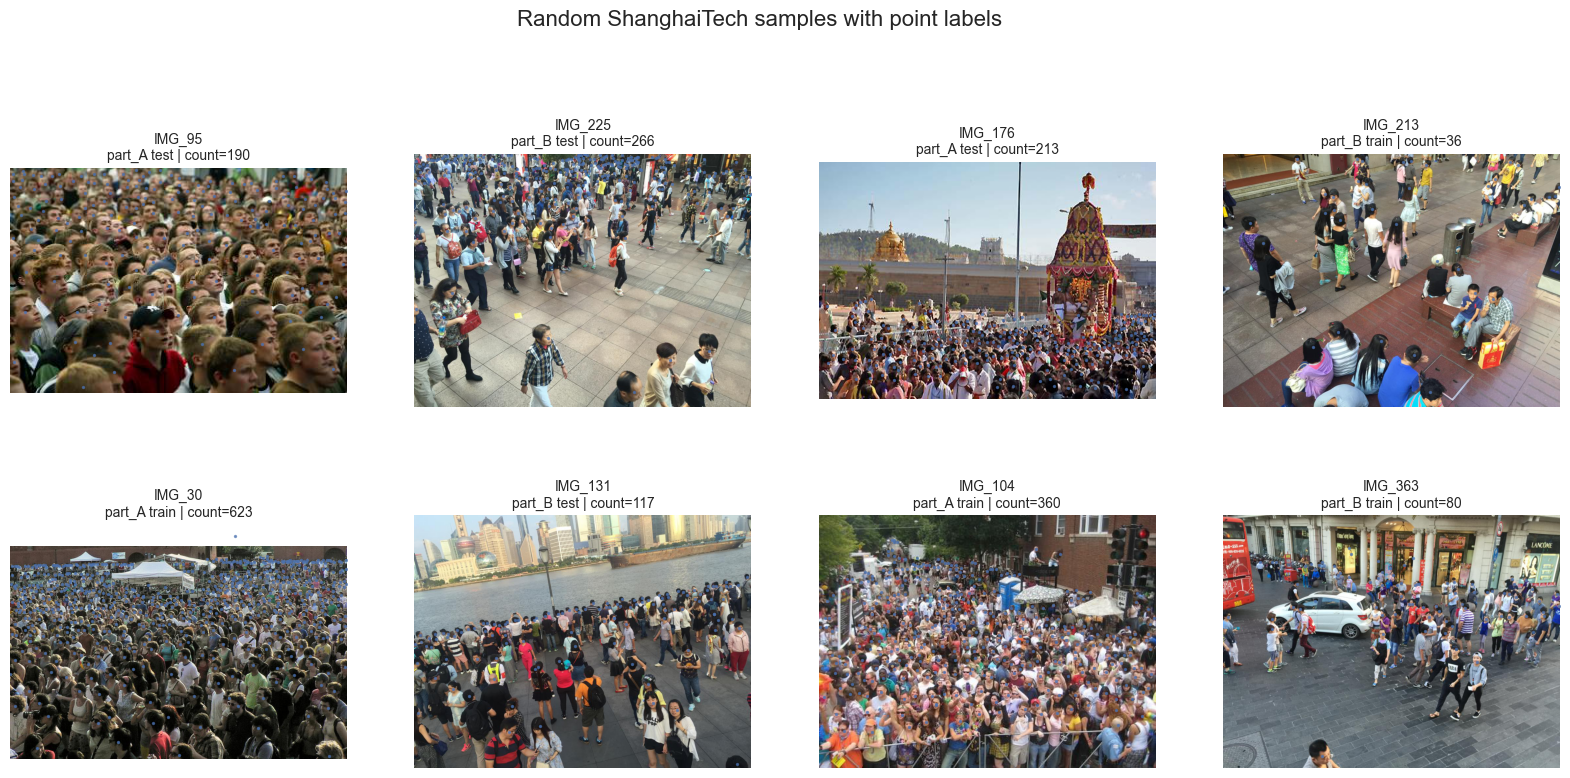

Saved: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_random_annotated_samples.png


In [12]:
sample = stratified_sample(labeled_df, ["part", "split"], n_each=2, seed=SEED)
plot_annotated_samples(sample, "Random ShanghaiTech samples with point labels", "shanghaitech_random_annotated_samples.png", max_points=2500, ncols=4)


## 12. Visual audit: lowest and highest counts


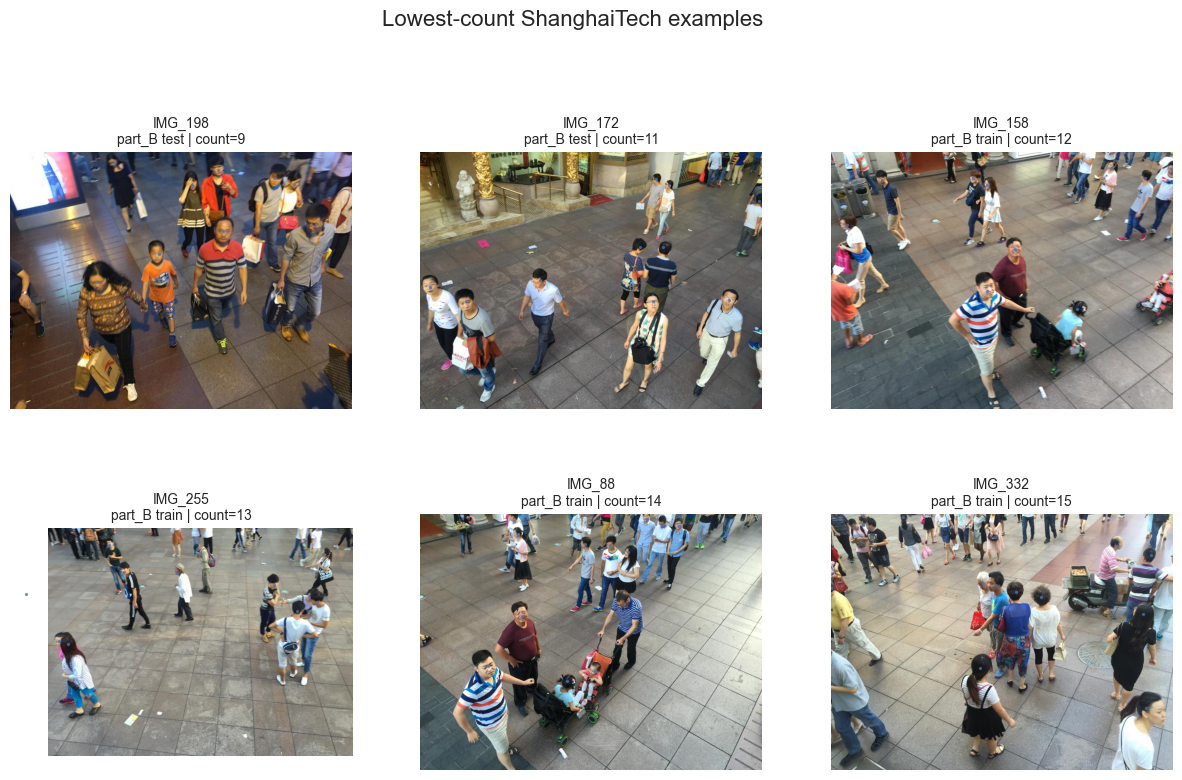

Saved: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_lowest_count_examples.png


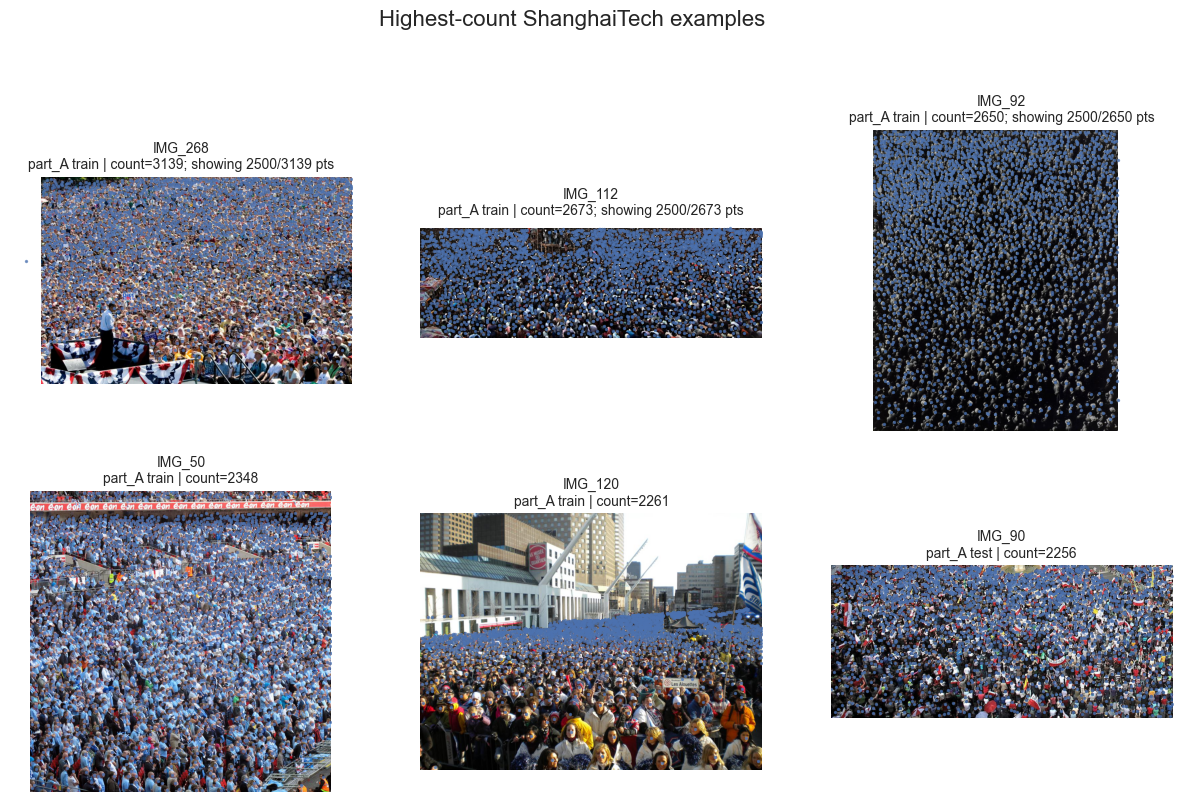

Saved: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_highest_count_examples.png


In [13]:
lowest = labeled_df.sort_values("count", ascending=True).head(6)
highest = labeled_df.sort_values("count", ascending=False).head(6)
plot_annotated_samples(lowest, "Lowest-count ShanghaiTech examples", "shanghaitech_lowest_count_examples.png", max_points=2500, ncols=3)
plot_annotated_samples(highest, "Highest-count ShanghaiTech examples", "shanghaitech_highest_count_examples.png", max_points=2500, ncols=3)


## 13. Normalized spatial annotation heatmaps

Each annotation is mapped to normalized image coordinates `(x / width, y / height)`. This highlights camera/framing biases independently of image size.


Loading points:   0%|          | 0/413 [00:00<?, ?it/s]

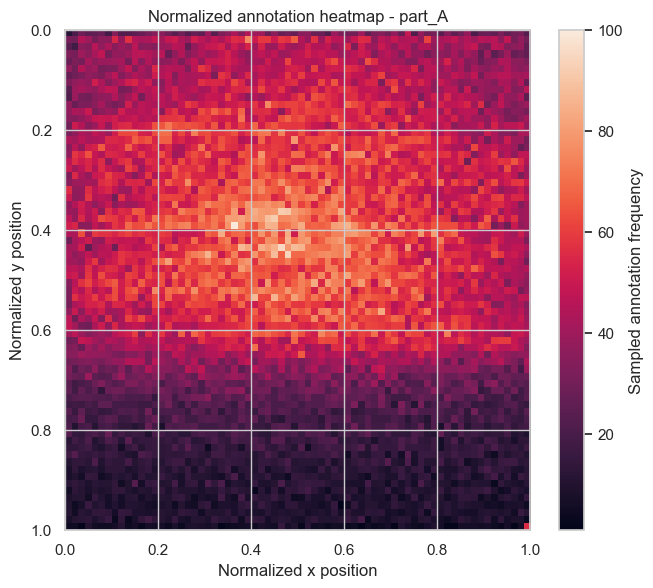

Saved: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_part_a_normalized_spatial_heatmap.png


Loading points:   0%|          | 0/618 [00:00<?, ?it/s]

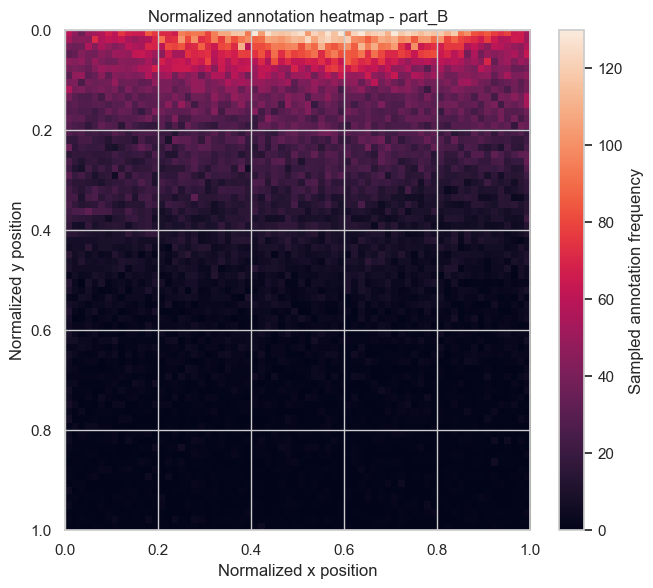

Saved: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_part_b_normalized_spatial_heatmap.png


In [14]:
for part in sorted(labeled_df["part"].dropna().unique()):
    part_df = labeled_df[labeled_df["part"] == part]
    plot_normalized_spatial_heatmap(
        part_df,
        title=f"Normalized annotation heatmap - {part}",
        filename=f"shanghaitech_{part.lower()}_normalized_spatial_heatmap.png",
        bins=70,
        max_points_per_image=1800,
    )


## 14. Density-map preview

This creates a visualization-only Gaussian density map from one high-count image. The exact training density map in the MCNN paper uses geometry-adaptive kernels for dense scenes; this preview is for EDA and sanity-checking only.


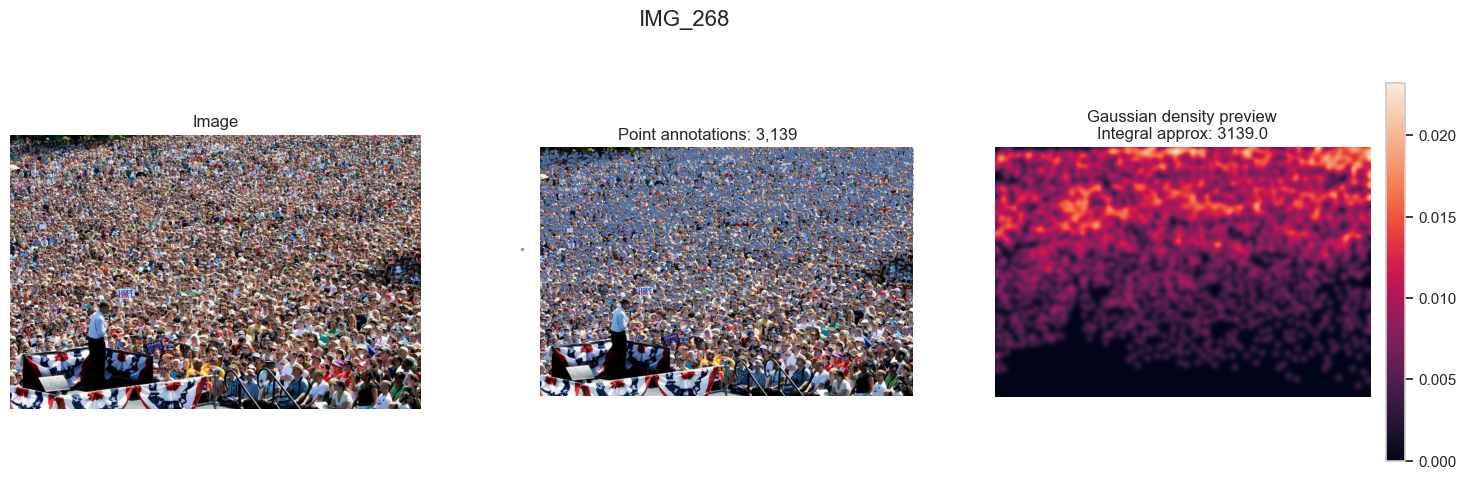

Saved: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_density_preview_high_count.png


In [15]:
row = labeled_df.sort_values("count", ascending=False).iloc[0]
make_density_preview(row, "shanghaitech_density_preview_high_count.png", max_side=900, sigma=7)


## 15. Export metadata

The exported CSV is useful for training scripts and for reproducible reporting.


In [16]:
metadata_path = OUTPUT_DIR / "shanghaitech_eda_metadata.csv"
df.to_csv(metadata_path, index=False)
print("Saved metadata:", metadata_path)

summary_path = OUTPUT_DIR / "shanghaitech_eda_summary.csv"
summary.to_csv(summary_path, index=False)
print("Saved summary:", summary_path)


Saved metadata: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_eda_metadata.csv
Saved summary: crowd_counting_eda_outputs\ShanghaiTech\shanghaitech_eda_summary.csv
